# Can I predict tonight's sleep score before going to bed?

The statistics notebook showed what correlates with sleep *after the night
happened*. This one asks the harder, more useful question: using only what is
known **before** the night (bedtime, day of week, recent sleep history,
today's activity), how well can tonight's score be forecast?

Method notes:
- **Time-based split**: train on the first ~80% of nights, test on the last ~20%.
  No shuffling - shuffling time series leaks the future into training.
- **Baselines first**: a model only earns its complexity if it beats the
  naive answers. Baselines: global mean, last-7-nights mean, same-weekday mean.
- Models: Ridge regression (interpretable coefficients), then a small
  RandomForest to check whether non-linearities add anything.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import create_engine
from dotenv import load_dotenv
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

load_dotenv("../.env")

SURFACE, INK, INK2, BLUE = "#fcfcfb", "#0b0b0b", "#52514e", "#2a78d6"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "text.color": INK, "axes.labelcolor": INK2,
    "xtick.color": INK2, "ytick.color": INK2,
    "axes.grid": True, "grid.color": "#e6e5e1", "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False, "font.size": 10,
})

engine = create_engine(os.environ["DATABASE_URL"])
df = pd.read_sql("""
    SELECT day, sleep_score, sleep_hours, bedtime_start_local,
           activity_score, steps
    FROM staging.daily ORDER BY day
""", engine, parse_dates=["day"]).set_index("day")
print(len(df), "days")

1244 days


## Feature engineering

Everything below is knowable before falling asleep. `bedtime_minutes` is
minutes after 18:00 (wraps past midnight). Activity features describe the
day that precedes the night: the ring assigns each night to the wake-up day,
so the relevant activity row is the previous calendar day's.

In [2]:
d = df.copy()

# Bedtime tonight, minutes after 18:00
bt = d["bedtime_start_local"]
mins = bt.dt.hour * 60 + bt.dt.minute
d["bedtime_minutes"] = np.where(mins >= 18 * 60, mins - 18 * 60, mins + 6 * 60)

# Day of week of the night (wake-day index: Monday=0 means Sunday night)
d["dow"] = d.index.dayofweek
d["is_sunday_night"] = (d.dow == 0).astype(int)
d["is_weekend_night"] = d.dow.isin([5, 6]).astype(int)

# History known before tonight
d["prev_score"] = d["sleep_score"].shift(1)
d["roll7_score"] = d["sleep_score"].shift(1).rolling(7, min_periods=4).mean()
d["prev_hours"] = d["sleep_hours"].shift(1)

# Activity of the day before the night = previous row's activity
d["day_activity"] = d["activity_score"].shift(1)
d["day_steps"] = d["steps"].shift(1)

FEATURES = ["bedtime_minutes", "is_sunday_night", "is_weekend_night",
            "prev_score", "roll7_score", "prev_hours",
            "day_activity", "day_steps"]
data = d[FEATURES + ["sleep_score", "dow"]].dropna()
print(len(data), "usable nights")

1222 usable nights


In [3]:
split = int(len(data) * 0.8)
train, test = data.iloc[:split], data.iloc[split:]
print(f"train: {train.index.min().date()} -> {train.index.max().date()}  (n={len(train)})")
print(f"test:  {test.index.min().date()} -> {test.index.max().date()}  (n={len(test)})")

y_tr, y_te = train["sleep_score"], test["sleep_score"]
results = {}

# Baseline 1: global mean of training set
results["global mean"] = mean_absolute_error(y_te, np.full(len(y_te), y_tr.mean()))

# Baseline 2: rolling 7-night mean (already a feature)
results["last-7-nights mean"] = mean_absolute_error(y_te, test["roll7_score"])

# Baseline 3: same-weekday training mean
dow_means = train.groupby("dow")["sleep_score"].mean()
results["same-weekday mean"] = mean_absolute_error(y_te, test["dow"].map(dow_means))

for k, v in results.items():
    print(f"{k:22s} MAE = {v:.2f}")

train: 2022-08-28 -> 2025-11-05  (n=977)
test:  2025-11-06 -> 2026-07-25  (n=245)
global mean            MAE = 9.14
last-7-nights mean     MAE = 9.13
same-weekday mean      MAE = 9.14


In [4]:
X_tr, X_te = train[FEATURES], test[FEATURES]

# Standardize for Ridge so coefficients are comparable
mu, sd = X_tr.mean(), X_tr.std()
ridge = Ridge(alpha=1.0).fit((X_tr - mu) / sd, y_tr)
results["ridge regression"] = mean_absolute_error(y_te, ridge.predict((X_te - mu) / sd))

rf = RandomForestRegressor(n_estimators=300, min_samples_leaf=5,
                           random_state=42).fit(X_tr, y_tr)
results["random forest"] = mean_absolute_error(y_te, rf.predict(X_te))

print(f"{'model':22s} {'MAE':>6s}")
for k, v in sorted(results.items(), key=lambda kv: kv[1]):
    print(f"{k:22s} {v:6.2f}")

model                     MAE
ridge regression         7.64
random forest            7.76
last-7-nights mean       9.13
same-weekday mean        9.14
global mean              9.14


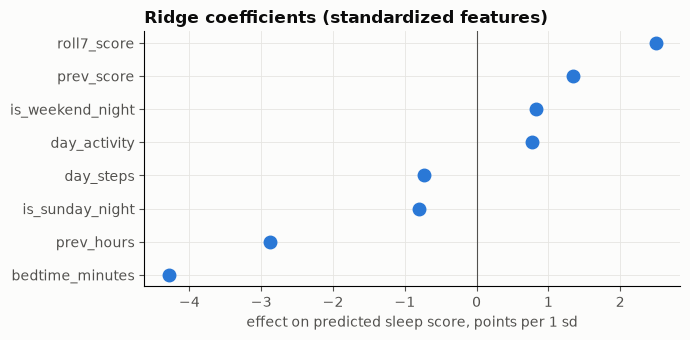

In [5]:
coefs = pd.Series(ridge.coef_, index=FEATURES).sort_values()

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(coefs.values, coefs.index, "o", color=BLUE, markersize=9)
ax.axvline(0, color=INK2, linewidth=0.8)
ax.set_title("Ridge coefficients (standardized features)",
             loc="left", fontweight="bold", color=INK)
ax.set_xlabel("effect on predicted sleep score, points per 1 sd")
plt.tight_layout(); plt.show()

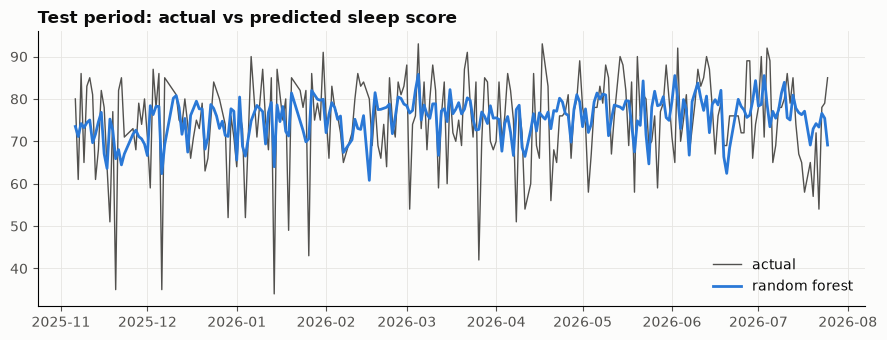

In [6]:
pred = rf.predict(X_te)
fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot(y_te.index, y_te.values, color=INK2, linewidth=1, label="actual")
ax.plot(y_te.index, pred, color=BLUE, linewidth=2, label="random forest")
ax.set_title("Test period: actual vs predicted sleep score",
             loc="left", fontweight="bold", color=INK)
ax.legend(frameon=False)
plt.tight_layout(); plt.show()

## Conclusions

- **The models earn their keep, modestly**: ridge regression MAE 7.64 against
  9.13 for the best baseline, a 16% improvement, with the random forest a
  little behind at 7.76. Tonight's sleep score is partly predictable before
  bed, but most night-to-night variation comes from things not in this feature
  set (stress, alcohol, illness, late meals). A modest, honestly evaluated gain
  is the correct result here; a model claiming to nail nightly sleep scores
  from these features would be leaking or overfitting.
- **The linear model wins, which is the right kind of boring.** With a
  correctly specified bedtime feature there is no non-linearity left for the
  forest to find, so the interpretable model is also the accurate one. Worth
  knowing that the forest previously looked better only because the feature it
  leaned on was wrong: bedtime was being read in UTC rather than local time
  (see the note in notebook 01), which flattened the strongest signal in the
  data and left curvature for the trees to chase.
- **Bedtime is the biggest controllable lever** by a wide margin, -4.29 points
  per standard deviation later, consistent with the timing finding in the
  README. The 7-night average (+2.49) says stable sleepers stay stable, and the
  negative coefficient on previous-night hours (-2.87) shows the
  rebound-oscillation pattern: an unusually long night tends to be followed by
  a weaker one.
- What could improve accuracy, honestly assessed: workout intensity and timing
  (1,100+ workouts already in the raw layer) and daily stress metrics
  (ingested) are the realistic additions. Lifestyle tags (alcohol, caffeine,
  illness) would likely matter most, but I rarely logged them, so that data
  effectively does not exist for the past. If I start logging them now, they
  become usable in a year. A model is only as good as what was actually
  recorded.